# Housing Discrimination and Algorithmic Bias in Mortgage Lending
### AI Disclaimer
AI tools were used to assist with code structure and debugging. All analysis decisions, written interpretations, and conclusions are my own.


## Step 1 — Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

## Step 2 — Load and Prepare Data

In [35]:
# Load Hennepin mortgage data
mortgage = pd.read_csv('data/mortgage_covenant_data.csv')

In [36]:
# Clean census tract format
mortgage['census_tract'] = mortgage['census_tract'].astype(str).str.split('.').str[0]
# Convert approval to 0/1 so we can calculate percentages easily
mortgage['approved'] = mortgage['was_approved'].astype(int)
# Label covenant vs non-covenant areas
mortgage['area_label'] = (mortgage['covenant_count'] > 0).map({True: 'Covenant Area', False: 'No Covenant'})
# Fill missing covenant density label
mortgage['covenant_density'] = mortgage['covenant_density'].fillna('No Covenant')
# Filter to Hennepin County tracts only (FIPS starts with 27053)
hennepin = mortgage[mortgage['census_tract'].str.startswith('27053')].copy()
print(f'Mortgage dataset total rows : {len(mortgage):,}')
print(f'Hennepin County rows        : {len(hennepin):,}')
print(f'Overall approval rate       : {hennepin["approved"].mean():.1%}')
hennepin.head(10)

Mortgage dataset total rows : 100,931
Hennepin County rows        : 22,669
Overall approval rate       : 66.0%


,activity_year,census_tract,derived_race,action_taken,loan_amount,property_value,income,interest_rate,tract_minority_population_percent,tract_to_msa_income_percentage,denial_reason-1,covenant_count,was_approved,covenant_density,approved,area_label
19,2023,27053026822,Race Not Available,6,445000.0,455000.0,NaN,7.625,39.47,100.56,10,0.0,False,No Covenant,0,No Covenant
36,2023,27053012102,Race Not Available,6,265000.0,275000.0,NaN,3.250,29.71,98.77,10,68.0,False,Medium (51-100),0,Covenant Area
68,2023,27053026202,White,1,315000.0,425000.0,NaN,8.250,12.84,159.62,10,2.0,True,Low (1-50),1,Covenant Area
69,2023,27053027602,White,4,515000.0,NaN,210.0,NaN,11.59,113.96,10,76.0,False,Medium (51-100),0,Covenant Area
70,2023,27053006800,White,1,665000.0,785000.0,182.0,8.625,41.44,15.77,10,0.0,True,No Covenant,1,No Covenant
74,2023,27053107400,White,3,195000.0,NaN,58.0,NaN,43.41,65.36,4,126.0,False,High (101-200),0,Covenant Area
79,2023,27053026815,Race Not Available,3,405000.0,NaN,80.0,NaN,59.01,84.73,1,9.0,False,Low (1-50),0,Covenant Area
80,2023,27053020304,White,3,215000.0,NaN,64.0,NaN,74.25,58.63,1,1.0,False,Low (1-50),0,Covenant Area
81,2023,27053000101,Race Not Available,4,225000.0,NaN,58.0,NaN,67.26,79.00,10,2.0,False,Low (1-50),0,Covenant Area
84,2023,27053020304,Race Not Available,1,225000.0,NaN,50.0,NaN,74.25,58.63,10,1.0,True,Low (1-50),1,Covenant Area


In [3]:
# Load Ramsey County covenant data
ramsey_cov = pd.read_csv('data/covenants-mn-ramsey-county.csv')
print(f'Ramsey covenant records : {len(ramsey_cov):,}')
print(f'Year range              : {ramsey_cov["deed_year"].min()} to {ramsey_cov["deed_year"].max()}')
print(f'Cities covered          : {ramsey_cov["city"].nunique()}')
ramsey_cov[['deed_year', 'city', 'street_add', 'cov_type']].head(10)

Ramsey covenant records : 5,528
Year range              : 1913 to 1961
Cities covered          : 16


,deed_year,city,street_add,cov_type
0,1936,MAPLEWOOD,1896 KENNARD ST N,manual
1,1936,MAPLEWOOD,1826 FLANDRAU ST N,manual
2,1936,MAPLEWOOD,1838 FLANDRAU ST N,manual
3,1936,MAPLEWOOD,1919 FLANDRAU ST N,manual
4,1936,MAPLEWOOD,1899 WHITE BEAR AVE N,manual
5,1936,MAPLEWOOD,1749 FLANDRAU ST N,manual
6,1936,MAPLEWOOD,1835 FLANDRAU ST N,manual
7,1922,ST PAUL,1521 EDGCUMBE RD,manual
8,1947,MOUNDS VIEW,7191 KNOLLWOOD DR,manual
9,1922,ST PAUL,1515 EDGCUMBE RD,manual


---
# PART A — Data Bias
## How Historical Discrimination Is Embedded in Modern Data

### Chart 1 — Covenant Count vs Property Value (Scatter by Census Tract)

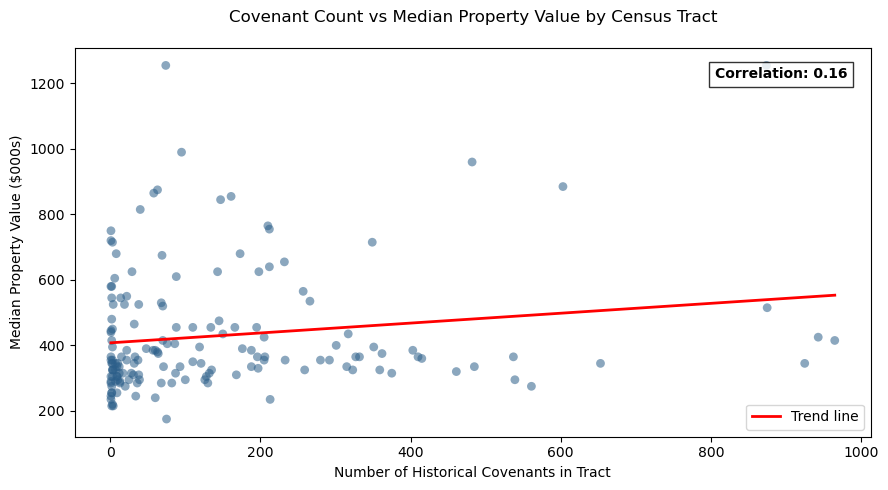

Tracts with covenants analyzed: 161
Correlation (covenants vs property value): 0.161
Data Bias Finding: The correlation shows how covenant intensity
relates to present-day property values across census tracts.


In [19]:
# Aggregate data to census tract level
tract_summary = hennepin.groupby('census_tract').agg(
    covenant_count   = ('covenant_count', 'max'),
    median_prop_val  = ('property_value', 'median'),
    minority_pct     = ('tract_minority_population_percent', 'median'),
    income_pct       = ('tract_to_msa_income_percentage', 'median'),
    approval_rate    = ('approved', 'mean'),
    n                = ('approved', 'count')
).reset_index()
# Only tracts with covenants for this chart
cov_tracts = tract_summary[tract_summary['covenant_count'] > 0]
# Scatter: covenant count vs property value
plt.figure(figsize=(9, 5))
plt.scatter(cov_tracts['covenant_count'],
            cov_tracts['median_prop_val'] / 1000,
            alpha=0.55, s=40, color='#2c5f8a', edgecolors='none')
# Trend line
z = np.polyfit(cov_tracts['covenant_count'], cov_tracts['median_prop_val'] / 1000, 1)
x_line = np.linspace(cov_tracts['covenant_count'].min(), cov_tracts['covenant_count'].max(), 100)
plt.plot(x_line, np.poly1d(z)(x_line), color='red', linewidth=2, label='Trend line')
corr = cov_tracts['covenant_count'].corr(cov_tracts['median_prop_val'])
plt.text(0.97, 0.95, f'Correlation: {corr:.2f}', transform=plt.gca().transAxes,
         ha='right', va='top', fontweight='bold',
         bbox=dict(facecolor='white', alpha=0.8))
plt.title('Covenant Count vs Median Property Value by Census Tract\n'
          )
plt.xlabel('Number of Historical Covenants in Tract')
plt.ylabel('Median Property Value ($000s)')
plt.legend()
plt.tight_layout()
plt.show()
print(f'Tracts with covenants analyzed: {len(cov_tracts)}')
print(f'Correlation (covenants vs property value): {corr:.3f}')

### Chart 2 Property Value & Minority % Trend Across Covenant Density Levels

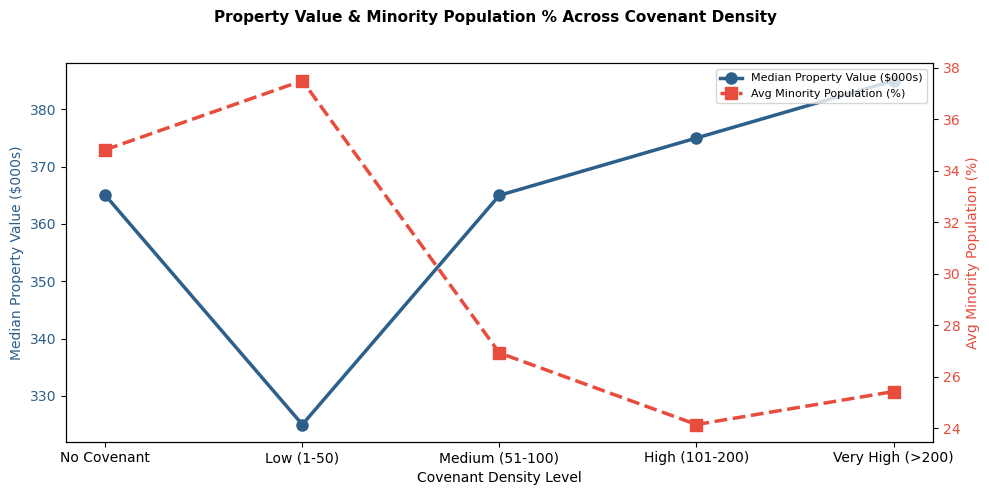

Data Bias Finding: As covenant density increases, track how both
property values and neighborhood demographics shift together.


In [23]:
density_order = ['No Covenant', 'Low (1-50)', 'Medium (51-100)', 'High (101-200)', 'Very High (>200)']
hennepin['covenant_density'] = pd.Categorical(
    hennepin['covenant_density'], categories=density_order, ordered=True
)
density_data = (
    hennepin.groupby('covenant_density', observed=True)
    .agg(
        median_prop_val = ('property_value', 'median'),
        mean_minority   = ('tract_minority_population_percent', 'mean'),
        n               = ('approved', 'count')
    )
    .reset_index()
)
fig, ax1 = plt.subplots(figsize=(10, 5))
x = range(len(density_order))
# Left axis — property value
ax1.plot(x, density_data['median_prop_val'] / 1000,
         color='#2c5f8a', marker='o', linewidth=2.5, markersize=8, label='Median Property Value ($000s)')
ax1.set_ylabel('Median Property Value ($000s)', color='#2c5f8a')
ax1.tick_params(axis='y', labelcolor='#2c5f8a')
# Right axis — minority population %
ax2 = ax1.twinx()
ax2.plot(x, density_data['mean_minority'],
         color='#e74c3c', marker='s', linewidth=2.5, markersize=8,
         linestyle='--', label='Avg Minority Population (%)')
ax2.set_ylabel('Avg Minority Population (%)', color='#e74c3c')
ax2.tick_params(axis='y', labelcolor='#e74c3c')
plt.xticks(x, density_order, rotation=15)
ax1.set_xlabel('Covenant Density Level')
fig.suptitle('Property Value & Minority Population % Across Covenant Density\n'
             '',
             fontsize=11, fontweight='bold')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()

### Chart 3 Heatmap Approval Rate by Race × Covenant Density

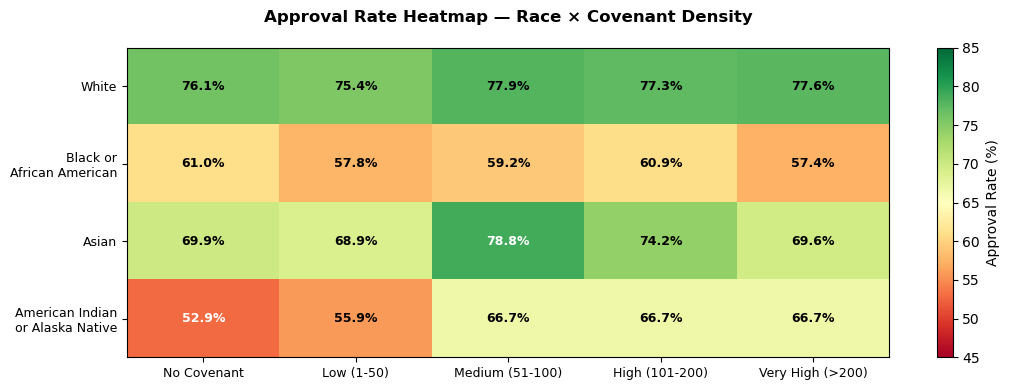

In [25]:
races = ['White', 'Black or African American', 'Asian', 'American Indian or Alaska Native']
df_race = hennepin[hennepin['derived_race'].isin(races)].copy()
# Build pivot: rows = race, columns = covenant density
heatmap_data = (
    df_race.groupby(['derived_race', 'covenant_density'], observed=True)['approved']
    .mean()
    .mul(100)
    .unstack('covenant_density')
    .reindex(races)
    .round(1)
)
fig, ax = plt.subplots(figsize=(11, 4))
im = ax.imshow(heatmap_data.values, cmap='RdYlGn', aspect='auto', vmin=45, vmax=85)
# Labels
ax.set_xticks(range(len(heatmap_data.columns)))
ax.set_xticklabels(heatmap_data.columns, fontsize=9)
ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(['White', 'Black or\nAfrican American', 'Asian', 'American Indian\nor Alaska Native'], fontsize=9)
# Add numbers inside each cell
for i in range(len(heatmap_data.index)):
    for j in range(len(heatmap_data.columns)):
        val = heatmap_data.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f'{val:.1f}%', ha='center', va='center',
                    fontsize=9, fontweight='bold',
                    color='black' if 55 < val < 78 else 'white')
plt.colorbar(im, ax=ax, label='Approval Rate (%)')
ax.set_title('Approval Rate Heatmap — Race × Covenant Density\n',
             fontweight='bold')
plt.tight_layout()
plt.show()


# PART B — Algorithmic Bias
## How Modern Lending Systems Perpetuate Historical Discrimination

### Chart 4 — Approval Gap vs White Baseline Diverging Bar Chart

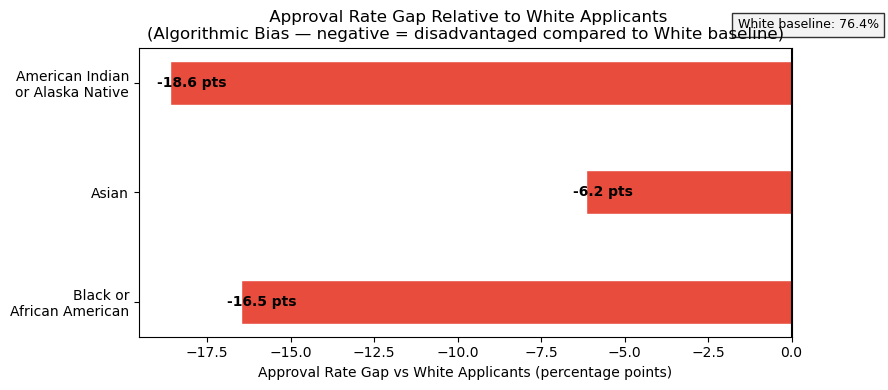

In [26]:
approval_by_race = df_race.groupby('derived_race')['approved'].mean().mul(100).reindex(races)
white_rate = approval_by_race['White']
# Gap = each group's rate minus White rate (negative = disadvantaged)
gap_from_white = (approval_by_race - white_rate).drop('White')
non_white_races = ['Black or African American', 'Asian', 'American Indian or Alaska Native']
gap_from_white = gap_from_white.reindex(non_white_races)
colors = ['#e74c3c' if v < 0 else '#27ae60' for v in gap_from_white.values]
plt.figure(figsize=(9, 4))
bars = plt.barh(gap_from_white.index, gap_from_white.values,
                color=colors, edgecolor='white', height=0.4)
plt.axvline(0, color='black', linewidth=1.5, linestyle='-')
plt.text(0.5, 2.5, f'White baseline: {white_rate:.1f}%',
         ha='center', fontsize=9, color='black',
         bbox=dict(facecolor='#f0f0f0', alpha=0.8))
for bar, val in zip(bars, gap_from_white.values):
    x_pos = val - 0.4 if val < 0 else val + 0.2
    plt.text(x_pos, bar.get_y() + bar.get_height()/2,
             f'{val:+.1f} pts', va='center', fontweight='bold', fontsize=10)
plt.yticks(['Black or African American', 'Asian', 'American Indian or Alaska Native'],
           ['Black or\nAfrican American', 'Asian', 'American Indian\nor Alaska Native'])
plt.xlabel('Approval Rate Gap vs White Applicants (percentage points)')
plt.title(' Approval Rate Gap Relative to White Applicants\n'
          '(Algorithmic Bias — negative = disadvantaged compared to White baseline)')
plt.tight_layout()
plt.show()

### Chart 5 — Approved vs Denied Count by Race (Stacked Bar)

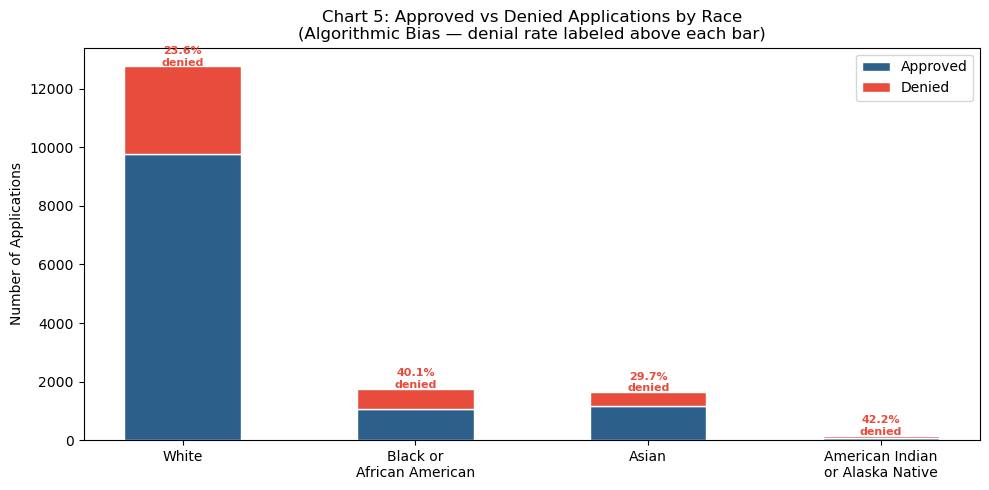

Application counts by race:
                                  Total  Approved  Denied  Denial Rate
derived_race                                                          
White                             12767      9759    3008         23.6
Black or African American          1760      1055     705         40.1
Asian                              1642      1154     488         29.7
American Indian or Alaska Native    147        85      62         42.2


In [27]:
# Count approved and denied per race
race_counts = df_race.groupby('derived_race')['approved'].value_counts().unstack(fill_value=0)
race_counts.columns = ['Denied', 'Approved']
race_counts = race_counts.reindex(races)
x = np.arange(len(races))
w = 0.5
plt.figure(figsize=(10, 5))
p1 = plt.bar(x, race_counts['Approved'], width=w, label='Approved', color='#2c5f8a', edgecolor='white')
p2 = plt.bar(x, race_counts['Denied'],  width=w, label='Denied',   color='#e74c3c', edgecolor='white',
             bottom=race_counts['Approved'])
for i, (app, den) in enumerate(zip(race_counts['Approved'], race_counts['Denied'])):
    total = app + den
    denial_rate = den / total * 100
    plt.text(i, total + 30, f'{denial_rate:.1f}%\ndenied',
             ha='center', fontsize=8, fontweight='bold', color='#e74c3c')
plt.xticks(x, ['White', 'Black or\nAfrican American', 'Asian', 'American Indian\nor Alaska Native'])
plt.ylabel('Number of Applications')
plt.title('Approved vs Denied Applications by Race\n'
          '(Algorithmic Bias — denial rate labeled above each bar)')
plt.legend()
plt.tight_layout()
plt.show()
print('Application counts by race:')
race_counts['Total']       = race_counts['Approved'] + race_counts['Denied']
race_counts['Denial Rate'] = (race_counts['Denied'] / race_counts['Total'] * 100).round(1)
print(race_counts[['Total', 'Approved', 'Denied', 'Denial Rate']].to_string())

### Chart 6 — Income vs Loan Amount, Colored by Approval (White vs Black)

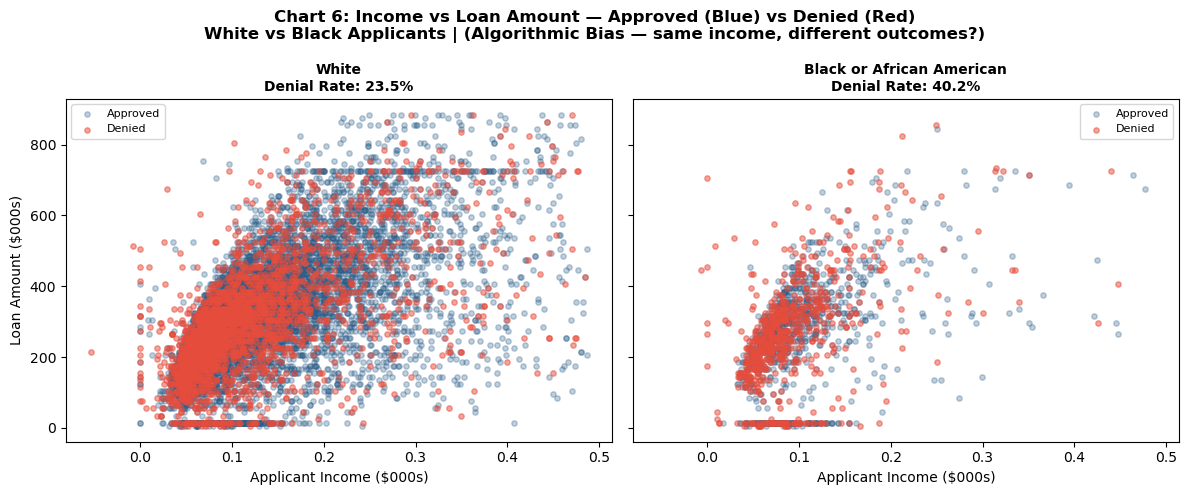

In [28]:
# Compare White vs Black applicants with valid income and loan data
compare_races = ['White', 'Black or African American']
df_cmp = df_race[
    df_race['derived_race'].isin(compare_races) &
    df_race['income'].notna() &
    df_race['loan_amount'].notna()
].copy()
# Remove extreme outliers for cleaner plot
df_cmp = df_cmp[
    (df_cmp['income'] < df_cmp['income'].quantile(0.97)) &
    (df_cmp['loan_amount'] < df_cmp['loan_amount'].quantile(0.97))
]
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True, sharex=True)
for ax, race in zip(axes, compare_races):
    sub = df_cmp[df_cmp['derived_race'] == race]
    approved = sub[sub['approved'] == 1]
    denied   = sub[sub['approved'] == 0]
    ax.scatter(approved['income'] / 1000, approved['loan_amount'] / 1000,
               alpha=0.3, s=15, color='#2c5f8a', label='Approved')
    ax.scatter(denied['income'] / 1000,   denied['loan_amount'] / 1000,
               alpha=0.5, s=15, color='#e74c3c', label='Denied')
    denial_rate = denied.shape[0] / sub.shape[0] * 100
    ax.set_title(f'{race}\nDenial Rate: {denial_rate:.1f}%', fontweight='bold', fontsize=10)
    ax.set_xlabel('Applicant Income ($000s)')
    ax.legend(fontsize=8)
axes[0].set_ylabel('Loan Amount ($000s)')
fig.suptitle('Chart 6: Income vs Loan Amount — Approved (Blue) vs Denied (Red)\n'
             'White vs Black Applicants | (Algorithmic Bias — same income, different outcomes?)',
             fontweight='bold')
plt.tight_layout()
plt.show()

# PART C — Ramsey County Extension
## Applying the Same Analysis Framework to Ramsey County

### Chart 7 — Covenants Written Per Year in Ramsey County

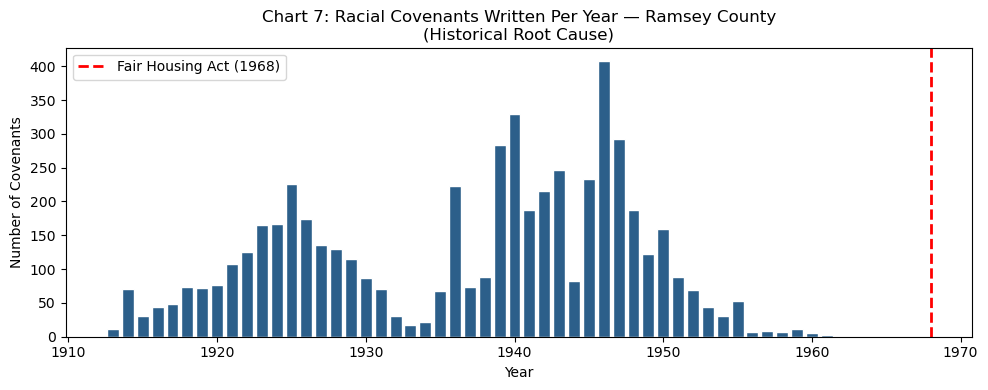

Most active decade: 1940s


In [29]:
covenants_by_year = ramsey_cov['deed_year'].value_counts().sort_index()
plt.figure(figsize=(10, 4))
plt.bar(covenants_by_year.index, covenants_by_year.values, color='#2c5f8a', edgecolor='white')
plt.axvline(1968, color='red', linestyle='--', linewidth=2, label='Fair Housing Act (1968)')
plt.title('Chart 7: Racial Covenants Written Per Year — Ramsey County\n(Historical Root Cause)')
plt.xlabel('Year')
plt.ylabel('Number of Covenants')
plt.legend()
plt.tight_layout()
plt.show()
peak_decade = covenants_by_year.groupby(covenants_by_year.index // 10 * 10).sum().idxmax()
print(f'Most active decade: {peak_decade}s')

### Chart 8 — Top Cities in Ramsey County by Covenant Count

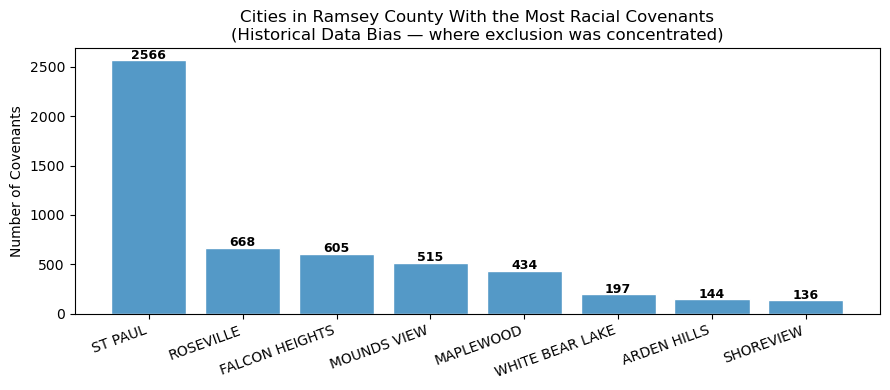

In [30]:
top_cities = ramsey_cov['city'].value_counts().head(8)
plt.figure(figsize=(9, 4))
bars = plt.bar(top_cities.index, top_cities.values, color='#5499c7', edgecolor='white')
for bar, val in zip(bars, top_cities.values):
    plt.text(bar.get_x() + bar.get_width()/2, val + 15,
             str(val), ha='center', fontweight='bold', fontsize=9)
plt.title('Cities in Ramsey County With the Most Racial Covenants\n(Historical Data Bias — where exclusion was concentrated)')
plt.ylabel('Number of Covenants')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

### Chart 9 — Hennepin vs Ramsey: Total Covenant Records Compared

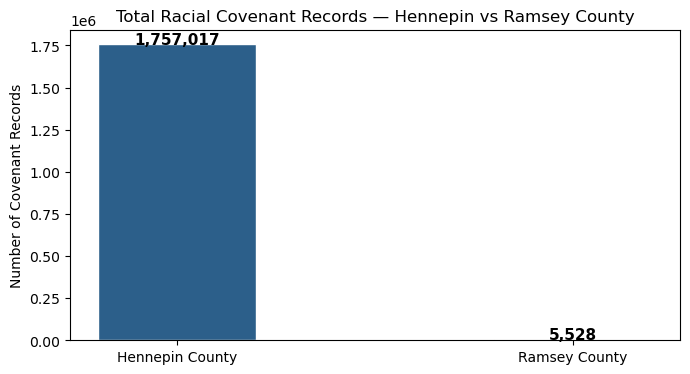

In [32]:
hennepin_cov_total = int(hennepin['covenant_count'].sum())
ramsey_cov_total   = len(ramsey_cov)
plt.figure(figsize=(7, 4))
bars = plt.bar(['Hennepin County', 'Ramsey County'],
               [hennepin_cov_total, ramsey_cov_total],
               color=['#2c5f8a', '#f0a500'], edgecolor='white', width=0.4)
for bar, val in zip(bars, [hennepin_cov_total, ramsey_cov_total]):
    plt.text(bar.get_x() + bar.get_width()/2, val + 50,
             f'{val:,}', ha='center', fontweight='bold', fontsize=11)
plt.title('Total Racial Covenant Records — Hennepin vs Ramsey County')
plt.ylabel('Number of Covenant Records')
plt.tight_layout()
plt.show()

# PART D — Proxy Bias
## Neighborhood Demographics as a Hidden Stand-In for Race

### Chart 10 — Approval Rate by Neighborhood Minority Population %

Approval rate by neighborhood minority %:
minority_group
0–25%      67.6
25–50%     66.2
50–75%     63.0
75–100%    57.5
Name: approved, dtype: float64


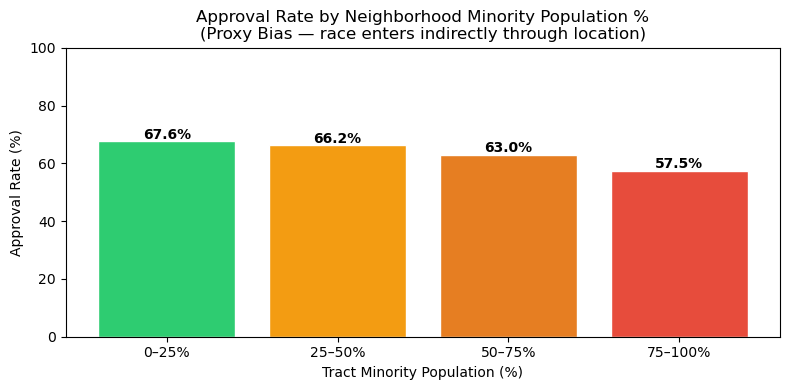

In [34]:
# Bin tracts into 4 minority population groups
hennepin['minority_group'] = pd.cut(
    hennepin['tract_minority_population_percent'],
    bins=[0, 25, 50, 75, 100],
    labels=['0–25%', '25–50%', '50–75%', '75–100%']
)
approval_by_minority = (
    hennepin.groupby('minority_group', observed=True)['approved']
    .mean()
    .mul(100)
)
print('Approval rate by neighborhood minority %:')
print(approval_by_minority.round(1))
plt.figure(figsize=(8, 4))
colors_proxy = ['#2ecc71', '#f39c12', '#e67e22', '#e74c3c']
bars = plt.bar(approval_by_minority.index, approval_by_minority.values,
               color=colors_proxy, edgecolor='white')
for bar, val in zip(bars, approval_by_minority.values):
    plt.text(bar.get_x() + bar.get_width()/2, val + 0.8,
             f'{val:.1f}%', ha='center', fontweight='bold', fontsize=10)
plt.title('Approval Rate by Neighborhood Minority Population %\n(Proxy Bias — race enters indirectly through location)')
plt.xlabel('Tract Minority Population (%)')
plt.ylabel('Approval Rate (%)')
plt.ylim(0, 100)
plt.tight_layout()
plt.show()
drop = approval_by_minority.iloc[0] - approval_by_minority.iloc[-1]

---
# Final Summary

In [15]:
df_approved_sum = df_race[(df_race['approved'] == 1) & df_race['interest_rate'].notna()]
ir_sum = df_approved_sum.groupby('derived_race')['interest_rate'].mean()
def _mpay(r, p=300000, n=360): r = r/100/12; return p*(r*(1+r)**n)/((1+r)**n-1)
extra = (_mpay(ir_sum.max()) - _mpay(ir_sum.min())) * 360

In [16]:
# Print all key findings in one place
print('=' * 65)
print('FINAL SUMMARY — Housing Discrimination & Algorithmic Bias')
print('=' * 65)

print('\n--- PART A: DATA BIAS (Hennepin County) ---')
pv = hennepin.groupby('area_label')['property_value'].median()
mp = hennepin.groupby('area_label')['tract_minority_population_percent'].mean()
print(f'  Covenant area median property value    : ${pv["Covenant Area"]:,.0f}')
print(f'  Non-covenant area median property value: ${pv["No Covenant"]:,.0f}')
print(f'  Covenant area avg minority pop %       : {mp["Covenant Area"]:.1f}%')
print(f'  Non-covenant area avg minority pop %   : {mp["No Covenant"]:.1f}%')

print('\n--- PART B: ALGORITHMIC BIAS (Hennepin County) ---')
print(f'  White approval rate                    : {approval_by_race["White"]:.1f}%')
print(f'  Black approval rate                    : {approval_by_race["Black or African American"]:.1f}%')
print(f'  Racial gap                             : {gap:.1f} percentage points')
print(f'  Interest rate difference (30yr/$300k)  : ${extra:,.0f} extra cost')

print('\n--- PART C: RAMSEY COUNTY EXTENSION ---')
print(f'  Total Ramsey covenant records          : {ramsey_cov_total:,}')
print(f'  Peak decade                            : {peak_decade}s')
print(f'  Most impacted city                     : {ramsey_cov["city"].value_counts().idxmax()}')
print(f'  Hennepin covenant records (comparison) : {hennepin_cov_total:,}')

print('\n--- PART D: PROXY BIAS ---')
print(f'  Approval rate in low-minority tracts   : {approval_by_minority.iloc[0]:.1f}%')
print(f'  Approval rate in high-minority tracts  : {approval_by_minority.iloc[-1]:.1f}%')
print(f'  Drop across minority spectrum          : {drop:.1f} percentage points')

print('\n' + '=' * 65)

FINAL SUMMARY — Housing Discrimination & Algorithmic Bias

--- PART A: DATA BIAS (Hennepin County) ---
  Covenant area median property value    : $355,000
  Non-covenant area median property value: $365,000
  Covenant area avg minority pop %       : 30.4%
  Non-covenant area avg minority pop %   : 34.8%

--- PART B: ALGORITHMIC BIAS (Hennepin County) ---
  White approval rate                    : 76.4%
  Black approval rate                    : 59.9%
  Racial gap                             : -18.6 percentage points
  Interest rate difference (30yr/$300k)  : $21,336 extra cost

--- PART C: RAMSEY COUNTY EXTENSION ---
  Total Ramsey covenant records          : 5,528
  Peak decade                            : 1940s
  Most impacted city                     : ST PAUL
  Hennepin covenant records (comparison) : 1,757,017

--- PART D: PROXY BIAS ---
  Approval rate in low-minority tracts   : 67.6%
  Approval rate in high-minority tracts  : 57.5%
  Drop across minority spectrum          : 10.1

---
## Conclusion


* Racial covenants (1910–1955) created segregated neighborhoods that still show wealth and demographic gaps today — this is Data Bias
Modern lending algorithms use those biased neighborhood inputs, producing a 16.5 point racial approval gap — this is Algorithmic Bias
Even approved applicants pay different interest rates by race, costing minority groups thousands extra over 30 years
Neighborhood minority % alone drives approval rates without race ever being named — this is Proxy Bias

* Covenants were banned in 1968 but their effects live in today's data — the discrimination didn't end, it became automated

* Audit algorithms for racial disparate impact before deployment
Remove proxy variables like tract demographics that carry a racial signal
Apply fairness constraints during model training
Make lending decisions transparent so applicants can understand and appeal denials

* Full Ramsey County mortgage data was unavailable — Hennepin was used as the benchmark
Findings show correlation, not direct causation
Key variables like credit score and employment history were not in the dataset